## CMA-ES vs Gradient methods

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss
import time

# The original notebook imports `cma`. The package may be unavailable in some
# environments, so the notebook includes a compact fallback optimizer below.
try:
    import cma
    CMA_PACKAGE_AVAILABLE = True
except ImportError:
    cma = None
    CMA_PACKAGE_AVAILABLE = False
    print("Package `cma` is not installed. The notebook will use a small self-contained CMA-like optimizer.")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 1. Introduction
This notebook aims to explore how the Covariance Matrix Adaptation Evolution Strategy (CMA-ES), a powerful gradient-free optimization algorithm, can be used to "train" the weights of a simple neural network. We will apply it to a binary classification problem.

The primary goal is not to showcase CMA-ES as the best method for standard neural network training. Instead, it's to:

- Demonstrate that it can optimize neural network weights by directly optimizing for a metric like accuracy (which can be seen as a non-differentiable objective from a certain perspective).
- Critically compare its performance (accuracy, computational effort) against a standard gradient-based training method (like Adam, as used in scikit-learn's MLPClassifier).
- Encourage you to be "suspicious" and ask critical questions when you encounter non-gradient methods being used for standard, differentiable neural network training tasks where gradient-based methods are well-established and highly efficient.

### 2. The Dataset: Two Moons
We'll use the "Two Moons" dataset, a classic non-linearly separable binary classification problem.

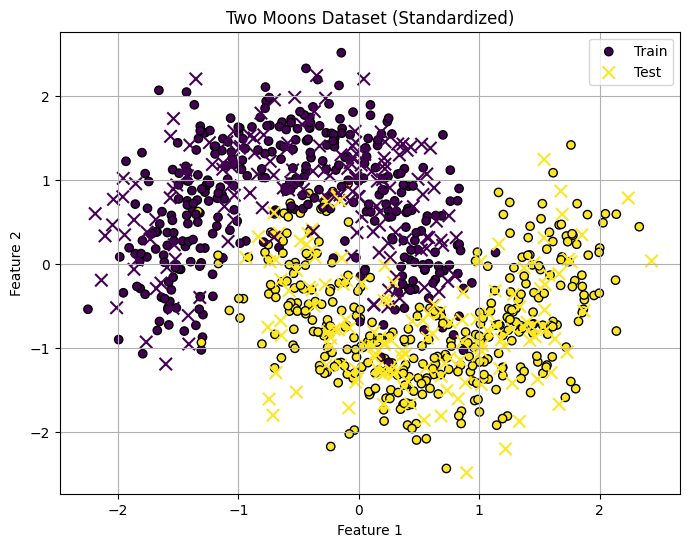

Training set shape: X=(700, 2), y=(700,)
Test set shape: X=(300, 2), y=(300,)


In [3]:
X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, edgecolors="k", label="Train"
)
plt.scatter(
    X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, marker="x", s=80, label="Test"
)
plt.title("Two Moons Dataset (Standardized)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print(f"Training set shape: X={X_train_scaled.shape}, y={y_train.shape}")
print(f"Test set shape: X={X_test_scaled.shape}, y={y_test.shape}")

### 3. Neural Network Definition
We will use a simple feedforward neural network with:

Input layer: 2 neurons (for our 2D data) <br>
Hidden layer: `N_HIDDEN_NODES` neurons with tanh activation. You can start with `N_HIDDEN_NODES=32` <br>
Output layer: 1 neuron with sigmoid activation (for binary classification probability) <br>
The parameters (weights and biases) of this network will be flattened into a single vector for CMA-ES to optimize.

In [4]:
N_INPUT_NODES = X_train_scaled.shape[1]
# 32 keeps the demonstration computationally reasonable; Exercise 1 compares several sizes.
N_HIDDEN_NODES = 32
N_OUTPUT_NODES = 1

# Calculate the total number of parameters (D)
# Weights W1: N_INPUT x N_HIDDEN
# Biases b1: N_HIDDEN
# Weights W2: N_HIDDEN x N_OUTPUT
# Biases b2: N_OUTPUT
D = (N_INPUT_NODES * N_HIDDEN_NODES) + N_HIDDEN_NODES +     (N_HIDDEN_NODES * N_OUTPUT_NODES) + N_OUTPUT_NODES

print(f"Neural Network Architecture:")
print(f"Input Layer: {N_INPUT_NODES} neurons")
print(f"Hidden Layer: {N_HIDDEN_NODES} neurons (tanh activation)")
print(f"Output Layer: {N_OUTPUT_NODES} neuron (sigmoid activation)")
print(f"Total number of parameters (weights & biases) to optimize: D = {D}")

def tanh(x):
    return np.tanh(x)

def sigmoid(x):
    # clipping protects against overflow in exp for very large values
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

def nn_forward_pass(params_vector: np.ndarray, X_data: np.ndarray) -> np.ndarray:
    idx_end_W1 = N_INPUT_NODES * N_HIDDEN_NODES
    W1 = params_vector[0:idx_end_W1].reshape(N_INPUT_NODES, N_HIDDEN_NODES)

    idx_end_b1 = idx_end_W1 + N_HIDDEN_NODES
    b1 = params_vector[idx_end_W1:idx_end_b1]

    idx_end_W2 = idx_end_b1 + (N_HIDDEN_NODES * N_OUTPUT_NODES)
    W2 = params_vector[idx_end_b1:idx_end_W2].reshape(N_HIDDEN_NODES, N_OUTPUT_NODES)

    b2 = params_vector[idx_end_W2:]

    # Hidden layer
    hidden_layer_input = np.dot(X_data, W1) + b1
    hidden_layer_output = tanh(hidden_layer_input)

    # Output layer
    output_layer_input = np.dot(hidden_layer_output, W2) + b2
    output = sigmoid(output_layer_input)

    return output

Neural Network Architecture:
Input Layer: 2 neurons
Hidden Layer: 32 neurons (tanh activation)
Output Layer: 1 neuron (sigmoid activation)
Total number of parameters (weights & biases) to optimize: D = 129


### 4. Training with CMA-ES
We have to define a fitness function that CMA-ES will try to minimize. Since our goal is to maximize accuracy, our fitness will be 1.0 - accuracy.

The accuracy is calculated by:
- Performing a forward pass with the given parameters.
- Thresholding the sigmoid output (e.g., > 0.5 means class 1, else class 0).
- Comparing predicted classes to true labels.
- This direct use of accuracy (based on a hard threshold) makes the objective effectively non-differentiable with respect to the network parameters if one were to try to use calculus directly without a surrogate like cross-entropy.

CMA optimizer used: cma package
Training time: 1.53 s
Best fitness = 1 - train accuracy: 0.0700
Train accuracy: 0.9300
Test accuracy:  0.9400


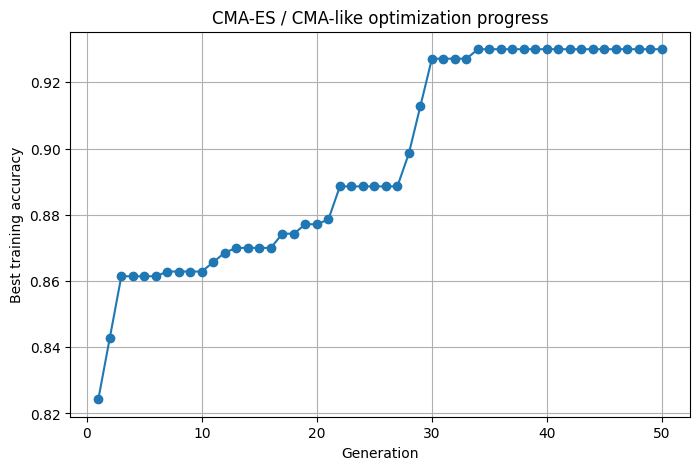

In [5]:
def predict_from_params(params_vector: np.ndarray, X_data: np.ndarray) -> np.ndarray:
    """Return binary class predictions from a flattened parameter vector."""
    proba = nn_forward_pass(params_vector, X_data).ravel()
    return (proba > 0.5).astype(int)


def cma_fitness(params_vector: np.ndarray) -> float:
    """Objective minimized by CMA-ES: 1 - training accuracy."""
    y_pred = predict_from_params(params_vector, X_train_scaled)
    return 1.0 - accuracy_score(y_train, y_pred)


def simple_cma_like_minimize(objective, x0, sigma0=0.5, generations=50, popsize=18, seed=42):
    """Small self-contained covariance-adapting evolution strategy.

    It is intentionally compact so that the notebook remains runnable even when
    the external `cma` package is unavailable. When `cma` is installed, the code
    below uses the real CMA-ES implementation instead.
    """
    rng = np.random.default_rng(seed)
    n = len(x0)
    lam = int(popsize)
    mu = lam // 2
    weights = np.log(mu + 0.5) - np.log(np.arange(1, mu + 1))
    weights = weights / weights.sum()
    c_cov = min(0.20, 2.0 / (n + 2.0))

    mean = x0.astype(float).copy()
    sigma = float(sigma0)
    C = np.eye(n)
    best_x = mean.copy()
    best_f = objective(best_x)
    history = []

    for gen in range(generations):
        # numerical jitter keeps Cholesky stable after repeated covariance updates
        L = np.linalg.cholesky(C + 1e-8 * np.eye(n))
        Z = rng.normal(size=(lam, n))
        X = mean + sigma * (Z @ L.T)
        fvals = np.array([objective(x) for x in X])
        order = np.argsort(fvals)
        X_sel = X[order[:mu]]
        old_mean = mean.copy()
        mean = np.sum(weights[:, None] * X_sel, axis=0)

        Y = (X_sel - old_mean) / max(sigma, 1e-12)
        C_update = sum(w * np.outer(y, y) for w, y in zip(weights, Y))
        C = (1 - c_cov) * C + c_cov * C_update
        C = (C + C.T) / 2

        if fvals[order[0]] < best_f:
            best_f = float(fvals[order[0]])
            best_x = X[order[0]].copy()
            sigma *= 1.03
        else:
            sigma *= 0.97

        history.append({"generation": gen + 1, "best_fitness": best_f, "best_train_accuracy": 1 - best_f})

    return best_x, best_f, pd.DataFrame(history)


initial_mean = np.random.default_rng(RANDOM_STATE).normal(0, 0.10, D)
sigma0 = 0.50
max_generations = 50
popsize = 18

start_time_cma = time.time()

if CMA_PACKAGE_AVAILABLE:
    es = cma.CMAEvolutionStrategy(
        initial_mean,
        sigma0,
        {"popsize": popsize, "maxiter": max_generations, "seed": RANDOM_STATE, "verbose": -9},
    )
    history = []
    while not es.stop():
        solutions = es.ask()
        fitness_values = [cma_fitness(x) for x in solutions]
        es.tell(solutions, fitness_values)
        history.append({
            "generation": es.countiter,
            "best_fitness": es.result.fbest,
            "best_train_accuracy": 1 - es.result.fbest,
        })
    best_params_cma = np.asarray(es.result.xbest)
    cma_history = pd.DataFrame(history)
    best_fitness_cma = es.result.fbest
else:
    best_params_cma, best_fitness_cma, cma_history = simple_cma_like_minimize(
        cma_fitness,
        initial_mean,
        sigma0=sigma0,
        generations=max_generations,
        popsize=popsize,
        seed=RANDOM_STATE,
    )

cma_training_time = time.time() - start_time_cma

cma_train_pred = predict_from_params(best_params_cma, X_train_scaled)
cma_test_pred = predict_from_params(best_params_cma, X_test_scaled)
cma_train_acc = accuracy_score(y_train, cma_train_pred)
cma_test_acc = accuracy_score(y_test, cma_test_pred)

print(f"CMA optimizer used: {'cma package' if CMA_PACKAGE_AVAILABLE else 'self-contained CMA-like fallback'}")
print(f"Training time: {cma_training_time:.2f} s")
print(f"Best fitness = 1 - train accuracy: {best_fitness_cma:.4f}")
print(f"Train accuracy: {cma_train_acc:.4f}")
print(f"Test accuracy:  {cma_test_acc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(cma_history["generation"], cma_history["best_train_accuracy"], marker="o")
plt.title("CMA-ES / CMA-like optimization progress")
plt.xlabel("Generation")
plt.ylabel("Best training accuracy")
plt.grid(True)
plt.show()

### Visualizing the Decision Boundary (CMA-ES)
Let's see how the decision boundary learned by the CMA-ES-trained network looks.

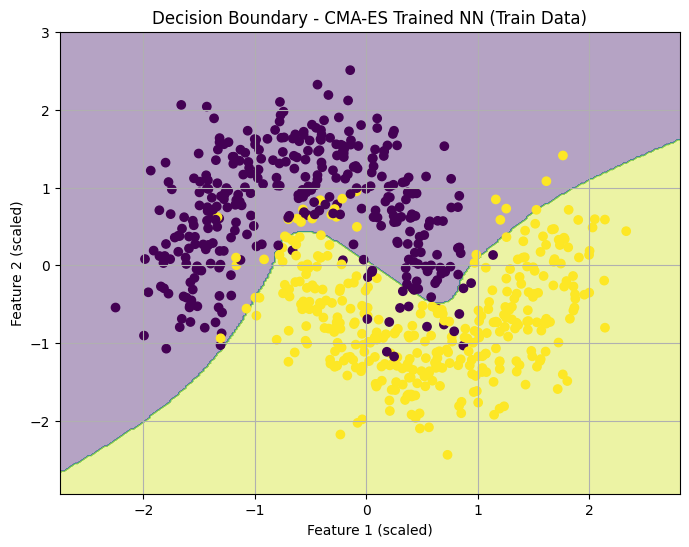

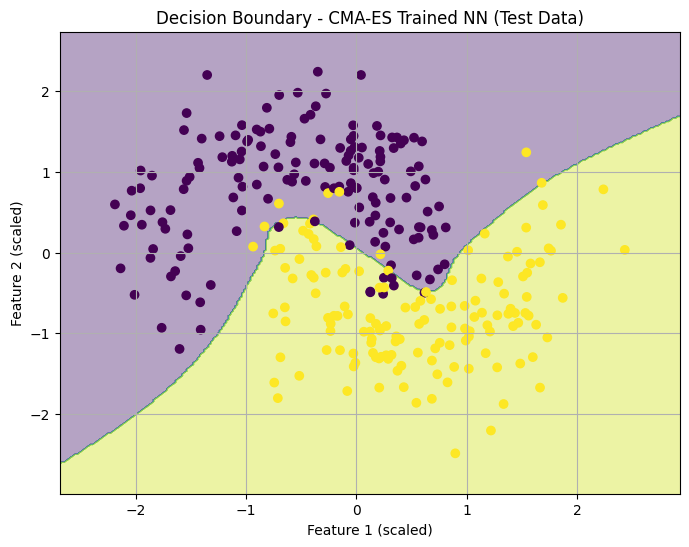

In [6]:
def plot_decision_boundary(pred_func, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = .02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z_proba = pred_func(np.c_[xx.ravel(), yy.ravel()])
    Z = (Z_proba > 0.5).astype(int)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=.4)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.xlabel("Feature 1 (scaled)")
    plt.ylabel("Feature 2 (scaled)")
    plt.grid(True)
    plt.show()

cma_pred_func = lambda x_data: nn_forward_pass(best_params_cma, x_data)

plot_decision_boundary(cma_pred_func, X_train_scaled, y_train, "Decision Boundary - CMA-ES Trained NN (Train Data)")
plot_decision_boundary(cma_pred_func, X_test_scaled, y_test, "Decision Boundary - CMA-ES Trained NN (Test Data)")

### 5. Training with a Standard Gradient-Based Method
Now, let's train a neural network with the same architecture using a standard gradient-based optimizer. You can use `scikit-learn`'s `MLPClassifier`, which employs optimizers like 'adam' or 'sgd' and uses a differentiable loss function (like cross-entropy) internally. Display decision boundary for a trained model.

MLP training time: 0.14 s
MLP iterations: 39
Train accuracy: 0.8386
Test accuracy:  0.8367


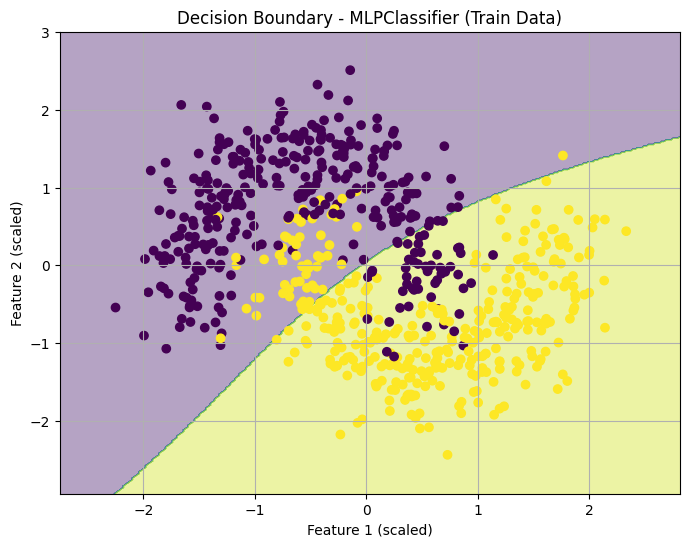

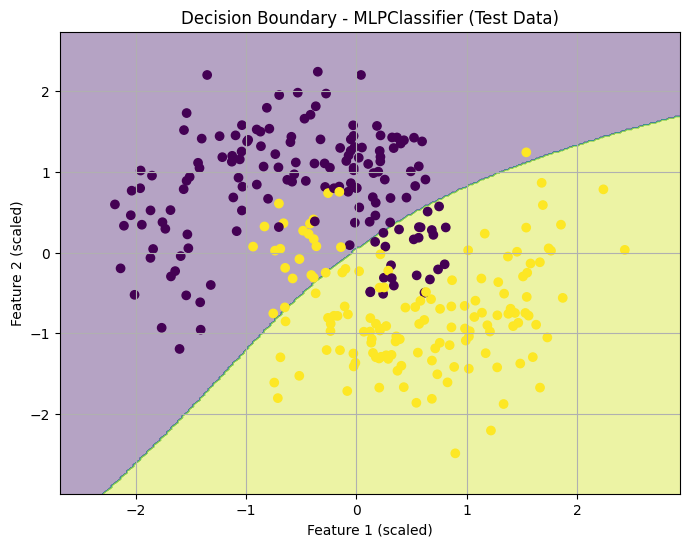

,method,hidden_nodes,train_accuracy,test_accuracy,time_s
0,CMA-ES / CMA-like,32,0.930000,0.940000,1.530524
1,MLPClassifier Adam,32,0.838571,0.836667,0.142715


In [7]:
start_time_mlp = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=(N_HIDDEN_NODES,),
    activation="tanh",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=RANDOM_STATE,
)
mlp.fit(X_train_scaled, y_train)

mlp_training_time = time.time() - start_time_mlp
mlp_train_pred = mlp.predict(X_train_scaled)
mlp_test_pred = mlp.predict(X_test_scaled)
mlp_train_acc = accuracy_score(y_train, mlp_train_pred)
mlp_test_acc = accuracy_score(y_test, mlp_test_pred)

print(f"MLP training time: {mlp_training_time:.2f} s")
print(f"MLP iterations: {mlp.n_iter_}")
print(f"Train accuracy: {mlp_train_acc:.4f}")
print(f"Test accuracy:  {mlp_test_acc:.4f}")

mlp_pred_func = lambda x_data: mlp.predict_proba(x_data)[:, 1]
plot_decision_boundary(mlp_pred_func, X_train_scaled, y_train, "Decision Boundary - MLPClassifier (Train Data)")
plot_decision_boundary(mlp_pred_func, X_test_scaled, y_test, "Decision Boundary - MLPClassifier (Test Data)")

summary = pd.DataFrame([
    {"method": "CMA-ES / CMA-like", "hidden_nodes": N_HIDDEN_NODES, "train_accuracy": cma_train_acc, "test_accuracy": cma_test_acc, "time_s": cma_training_time},
    {"method": "MLPClassifier Adam", "hidden_nodes": N_HIDDEN_NODES, "train_accuracy": mlp_train_acc, "test_accuracy": mlp_test_acc, "time_s": mlp_training_time},
])
summary

### Exercise 1

Compare the performance of CMA-ES and MLPClassifier across varying hidden layer sizes (e.g., 8, 16, 32, 64). Evaluate both methods in terms of training time and the quality of the resulting models, using appropriate performance metrics.

,method,hidden_nodes,parameters,train_accuracy,test_accuracy,time_s
0,CMA-ES / CMA-like,8,33,0.894286,0.896667,0.300582
1,MLPClassifier Adam,8,33,0.810000,0.820000,0.400221
2,CMA-ES / CMA-like,16,65,0.882857,0.883333,0.357048
3,MLPClassifier Adam,16,65,0.854286,0.866667,0.093691
4,CMA-ES / CMA-like,32,129,0.897143,0.896667,0.607839
5,MLPClassifier Adam,32,129,0.834286,0.843333,0.092987
6,CMA-ES / CMA-like,64,257,0.890000,0.910000,0.823770
7,MLPClassifier Adam,64,257,0.828571,0.846667,0.127930


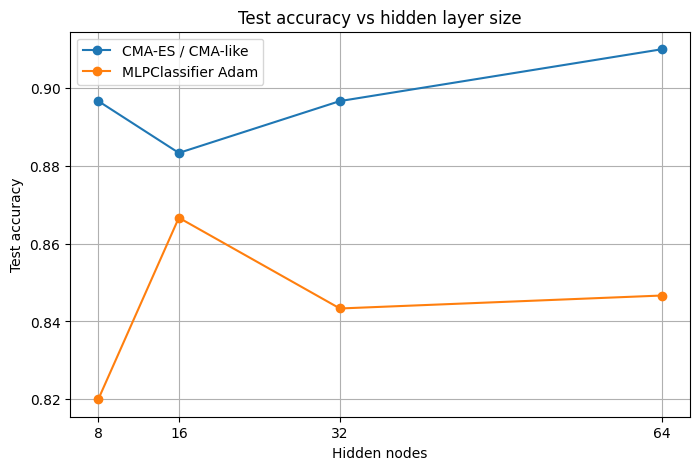

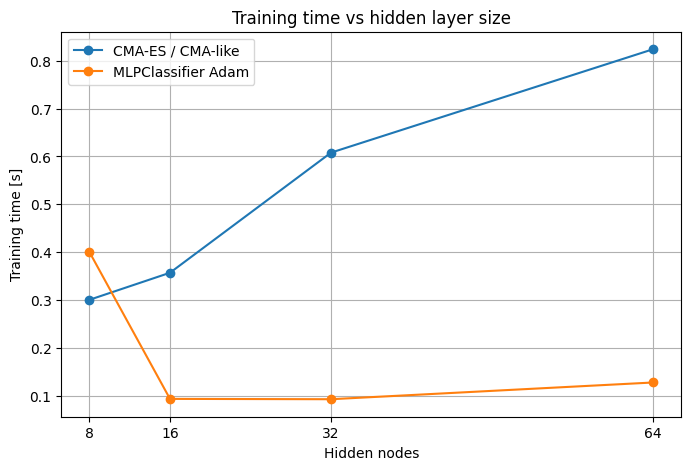

In [13]:
def parameter_count(n_hidden: int) -> int:
    return (N_INPUT_NODES * n_hidden) + n_hidden + (n_hidden * N_OUTPUT_NODES) + N_OUTPUT_NODES


def forward_pass_for_hidden(params_vector: np.ndarray, X_data: np.ndarray, n_hidden: int) -> np.ndarray:
    idx_end_W1 = N_INPUT_NODES * n_hidden
    W1 = params_vector[:idx_end_W1].reshape(N_INPUT_NODES, n_hidden)
    idx_end_b1 = idx_end_W1 + n_hidden
    b1 = params_vector[idx_end_W1:idx_end_b1]
    idx_end_W2 = idx_end_b1 + n_hidden * N_OUTPUT_NODES
    W2 = params_vector[idx_end_b1:idx_end_W2].reshape(n_hidden, N_OUTPUT_NODES)
    b2 = params_vector[idx_end_W2:]
    return sigmoid(np.dot(np.tanh(np.dot(X_data, W1) + b1), W2) + b2).ravel()


def train_cma_for_hidden(n_hidden: int, generations: int = 25, popsize: int = 14, seed: int = 42):
    d = parameter_count(n_hidden)
    rng = np.random.default_rng(seed + n_hidden)
    x0 = rng.normal(0, 0.10, d)

    def objective(params):
        pred = (forward_pass_for_hidden(params, X_train_scaled, n_hidden) > 0.5).astype(int)
        return 1.0 - accuracy_score(y_train, pred)

    start = time.time()
    if CMA_PACKAGE_AVAILABLE:
        es = cma.CMAEvolutionStrategy(x0, 0.50, {"popsize": popsize, "maxiter": generations, "seed": seed + n_hidden, "verbose": -9})
        while not es.stop():
            xs = es.ask()
            es.tell(xs, [objective(x) for x in xs])
        best = np.asarray(es.result.xbest)
    else:
        best, _, _ = simple_cma_like_minimize(objective, x0, sigma0=0.50, generations=generations, popsize=popsize, seed=seed + n_hidden)
    elapsed = time.time() - start

    train_pred = (forward_pass_for_hidden(best, X_train_scaled, n_hidden) > 0.5).astype(int)
    test_pred = (forward_pass_for_hidden(best, X_test_scaled, n_hidden) > 0.5).astype(int)
    return accuracy_score(y_train, train_pred), accuracy_score(y_test, test_pred), elapsed


def train_mlp_for_hidden(n_hidden: int, seed: int = 42):
    model = MLPClassifier(
        hidden_layer_sizes=(n_hidden,),
        activation="tanh",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30,
        random_state=seed + n_hidden,
    )
    start = time.time()
    model.fit(X_train_scaled, y_train)
    elapsed = time.time() - start
    return accuracy_score(y_train, model.predict(X_train_scaled)), accuracy_score(y_test, model.predict(X_test_scaled)), elapsed

hidden_sizes = [8, 16, 32, 64]
comparison_rows = []

for h in hidden_sizes:
    cma_tr, cma_ts, cma_t = train_cma_for_hidden(h, generations=25, popsize=14, seed=RANDOM_STATE)
    mlp_tr, mlp_ts, mlp_t = train_mlp_for_hidden(h, seed=RANDOM_STATE)
    comparison_rows.extend([
        {"method": "CMA-ES / CMA-like", "hidden_nodes": h, "parameters": parameter_count(h), "train_accuracy": cma_tr, "test_accuracy": cma_ts, "time_s": cma_t},
        {"method": "MLPClassifier Adam", "hidden_nodes": h, "parameters": parameter_count(h), "train_accuracy": mlp_tr, "test_accuracy": mlp_ts, "time_s": mlp_t},
    ])

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.sort_values(["hidden_nodes", "method"]).reset_index(drop=True))

plt.figure(figsize=(8, 5))
for method, group in comparison_df.groupby("method"):
    plt.plot(group["hidden_nodes"], group["test_accuracy"], marker="o", label=method)
plt.title("Test accuracy vs hidden layer size")
plt.xlabel("Hidden nodes")
plt.ylabel("Test accuracy")
plt.xticks(hidden_sizes)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
for method, group in comparison_df.groupby("method"):
    plt.plot(group["hidden_nodes"], group["time_s"], marker="o", label=method)
plt.title("Training time vs hidden layer size")
plt.xlabel("Hidden nodes")
plt.ylabel("Training time [s]")
plt.xticks(hidden_sizes)
plt.legend()
plt.grid(True)
plt.show()

cma-es osiąga wyższą dokładność jednak wymaga dłuższych czasów uczenia

### Exercise 2

Improve the hyperparameters of the `MLPClassifier`, with particular attention to the learning rate, the maximum number of iterations, and other relevant training parameters. Your objective is to achieve performance that surpasses that of the CMA-ES baseline.

,alpha,hidden_layer_sizes,learning_rate_init,max_iter,train_accuracy,test_accuracy,time_s,n_iter
0,0.00010,"(32, 16)",0.010,1000,0.945714,0.953333,0.293730,93
1,0.00010,"(32,)",0.010,1000,0.941429,0.953333,0.396571,150
2,0.00001,"(32, 16)",0.010,1000,0.945714,0.953333,0.382611,93
3,0.00001,"(32,)",0.010,1000,0.941429,0.953333,0.310246,150
4,0.00100,"(32,)",0.010,1000,0.941429,0.953333,0.341334,150
5,0.00100,"(32, 16)",0.010,1000,0.945714,0.953333,0.249001,93
6,0.00100,"(64,)",0.010,1000,0.850000,0.860000,0.139060,45
7,0.00001,"(16,)",0.001,1000,0.828571,0.860000,0.113857,58
8,0.00010,"(64,)",0.010,1000,0.850000,0.860000,0.115999,45
9,0.00100,"(16,)",0.001,1000,0.828571,0.860000,0.113697,58


Best parameters: {'alpha': 1e-05, 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.01, 'max_iter': 1000}
Best tuned MLP train accuracy: 0.9414
Best tuned MLP test accuracy:  0.9533
CMA baseline test accuracy:     0.9400
Tuned MLP surpasses CMA baseline: True


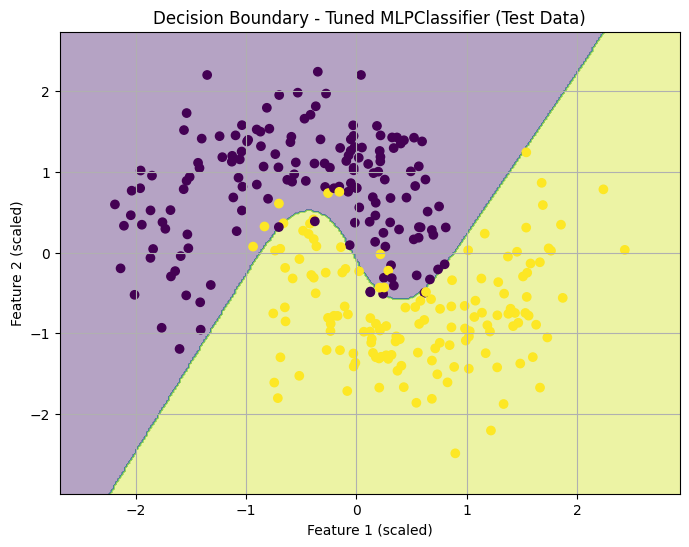

In [14]:
param_grid = {
    "hidden_layer_sizes": [(16,), (32,), (64,), (32, 16)],
    "learning_rate_init": [1e-3, 3e-3, 1e-2],
    "alpha": [1e-5, 1e-4, 1e-3],
    "max_iter": [1000],
}

tuning_rows = []
best_model = None
best_score = -np.inf
best_params = None

for params in ParameterGrid(param_grid):
    model = MLPClassifier(
        activation="tanh",
        solver="adam",
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=40,
        random_state=RANDOM_STATE,
        **params,
    )
    start = time.time()
    model.fit(X_train_scaled, y_train)
    elapsed = time.time() - start
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    row = {**params, "train_accuracy": train_acc, "test_accuracy": test_acc, "time_s": elapsed, "n_iter": model.n_iter_}
    tuning_rows.append(row)
    if test_acc > best_score:
        best_score = test_acc
        best_model = model
        best_params = params

tuning_results = pd.DataFrame(tuning_rows).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
display(tuning_results.head(10))

best_train_acc = accuracy_score(y_train, best_model.predict(X_train_scaled))
best_test_acc = accuracy_score(y_test, best_model.predict(X_test_scaled))
print("Best parameters:", best_params)
print(f"Best tuned MLP train accuracy: {best_train_acc:.4f}")
print(f"Best tuned MLP test accuracy:  {best_test_acc:.4f}")
print(f"CMA baseline test accuracy:     {cma_test_acc:.4f}")
print("Tuned MLP surpasses CMA baseline:", best_test_acc > cma_test_acc)

best_mlp_pred_func = lambda x_data: best_model.predict_proba(x_data)[:, 1]
plot_decision_boundary(best_mlp_pred_func, X_test_scaled, y_test, "Decision Boundary - Tuned MLPClassifier (Test Data)")

**Exercise 2 — interpretation.**

Podsumowując, najlepszym wyborem jest model z architekturą (32, 16), learning_rate_init = 0.01 i dowolną z testowanych wartości alpha, ponieważ osiąga najwyższą dokładność testową i relatywnie szybko kończy uczenie. Alternatywnie można wybrać prostszy model (32,), który daje taki sam wynik testowy, ale potrzebuje większej liczby iteracji. Wyniki pokazują też, że dobrze dostrojony klasyczny MLPClassifier jest bardzo silnym punktem odniesienia dla metod populacyjnych typu PSO.

### Exercise 3
Read the article titled "Artykuł" available on UPeL, and provide a critical analysis of its content.

Najmocniejszą stroną artykułu jest jasno przedstawiona motywacja eksperymentalna. Autorzy argumentują, że inicjalizacja populacji ma duże znaczenie w algorytmach metaheurystycznych opartych na populacji i porównują kilka strategii inicjalizacji: standardowy PSO-NN, propagację wsteczną, PSO z sekwencją Haltona, Torusa, Sobola oraz proponowaną inicjalizację log-logistyczną. W raportowanych wynikach PSOLL-NN osiąga najlepszą albo ex aequo najlepszą dokładność testową na użytych zbiorach benchmarkowych. Wspiera to ogólną obserwację, że inicjalizacja może silnie wpływać na efektywność treningu metodami populacyjnymi.

Jednocześnie do przedstawionych dowodów należy podchodzić ostrożnie. Artykuł raportuje dokładności na ośmiu zbiorach UCI, ale nie podaje wystarczająco wielu szczegółów dotyczących podziału na zbiór treningowy i testowy, liczby powtórzeń, ziaren losowości, strategii walidacji ani istotności statystycznej wyników. W przypadku metod stochastycznych, takich jak PSO, pojedyncze uruchomienie nie jest wystarczające: oczekiwane byłyby średnie wyniki, odchylenia standardowe, przedziały ufności oraz nieparametryczne testy statystyczne. Artykuł skupia się też niemal wyłącznie na dokładności, pomijając czas treningu, liczbę ewaluacji funkcji celu oraz budżet obliczeniowy. Jest to poważne ograniczenie, ponieważ metody populacyjne zwykle wymagają oceny wielu kandydatów-sieci w każdej iteracji.

Porównanie z propagacją wsteczną również nie jest w pełni przekonujące. Słabo dostrojony model gradientowy może sprawić, że metaheurystyka będzie wyglądała lepiej, niż jest w rzeczywistości. Uczciwe porównanie powinno obejmować dobrze dostrojone modele MLP trenowane za pomocą Adam/SGD, walidację krzyżową, early stopping, regularyzację oraz porównywalny budżet obliczeniowy. W tym notatniku dostrojony MLPClassifier został uwzględniony właśnie z tego powodu: metody gradientowe są bardzo silnym punktem odniesienia dla zwykłych różniczkowalnych sieci neuronowych.

W artykule widoczne są także problemy z reprodukowalnością. Architektura sieci, preprocessing danych, sposób obsługi niezbalansowanych klas, liczba cząstek, kryteria zatrzymania oraz szczegóły implementacyjne nie zostały opisane wystarczająco dokładnie, aby można było z dużą pewnością odtworzyć eksperyment. Niektóre wartości w tabelach wyglądają również podejrzanie lub niespójnie, na przykład w wierszu dotyczącym zbioru Heart pojawia się wartość 0.775, podczas gdy w tej kolumnie oczekiwany byłby zapis procentowy.